In [14]:
import numpy as np
import pandas as pd
import sklearn as sk
import yfinance as yf
import matplotlib.pyplot as plt

In [15]:
data = yf.download("TATAGOLD.NS", start="2024-12-01", end="2026-03-03")
data.to_csv("TATAGOLDETF.csv")

/tmp/ipykernel_311/1450006312.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TATAGOLD.NS", start="2024-12-01", end="2026-03-03")
[*********************100%***********************]  1 of 1 completed


In [16]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS
Date,,,,,
2024-12-02,7.50,7.68,7.46,7.53,6083489
2024-12-03,7.52,7.54,7.50,7.50,4934156
2024-12-04,7.52,7.57,7.50,7.57,6886317
2024-12-05,7.53,7.56,7.52,7.55,4217288
2024-12-06,7.52,7.57,7.49,7.55,4664698


In [17]:
data.info
data.isnull()

Price,Close,High,Low,Open,Volume
Ticker,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS,TATAGOLD.NS
Date,,,,,
2024-12-02,False,False,False,False,False
2024-12-03,False,False,False,False,False
2024-12-04,False,False,False,False,False
2024-12-05,False,False,False,False,False
2024-12-06,False,False,False,False,False
...,...,...,...,...,...
2026-02-24,False,False,False,False,False
2026-02-25,False,False,False,False,False


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(data['Close'].values.reshape(-1,1))
scaled_data = scaler.transform(data['Close'].values.reshape(-1,1))
scaled_data

array([[0.00504543],
       [0.00706359],
       [0.00706359],
       [0.00807269],
       [0.00706359],
       [0.01009086],
       [0.01412718],
       [0.02119072],
       [0.02522704],
       [0.01412718],
       [0.01210902],
       [0.00807269],
       [0.01009086],
       [0.00403632],
       [0.        ],
       [0.00403632],
       [0.00302727],
       [0.00504543],
       [0.00908175],
       [0.00605453],
       [0.00706359],
       [0.01009086],
       [0.01311807],
       [0.0181635 ],
       [0.01210902],
       [0.01311807],
       [0.01917256],
       [0.02018166],
       [0.02421798],
       [0.03329974],
       [0.02926336],
       [0.03027247],
       [0.03430879],
       [0.03834511],
       [0.03733606],
       [0.04036328],
       [0.04843592],
       [0.04641776],
       [0.05045408],
       [0.04843592],
       [0.04843592],
       [0.05348135],
       [0.05549951],
       [0.06659937],
       [0.0716448 ],
       [0.07265391],
       [0.07870834],
       [0.092

In [19]:
training_data_len = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len - 60:, :]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

Training data length: 248
Testing data length: 123


In [20]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 60
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (187, 60)
Shape of y_train: (187,)
Shape of X_test: (62, 60)
Shape of y_test: (62,)


In [21]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Reshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")

Reshaped X_train shape: (187, 60, 1)
Reshaped X_test shape: (62, 60, 1)


In [22]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(100, return_sequences=False))
model.add(Dense(50))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [24]:
model.fit(X_train, y_train, batch_size=1, epochs=10)

Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - loss: 0.0059
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.0012
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - loss: 0.0012
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 9.3838e-04
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - loss: 6.4896e-04
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 7.7648e-04
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 7.2772e-04
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 5.9122e-04
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 5.3053e-04
Epoch 10/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - loss: 5.6389e-04


In [25]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 351ms/step


In [26]:
predictions = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

In [27]:
rmse = np.sqrt(np.mean(((predictions - y_test_inverse)**2)))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.5030766305086154


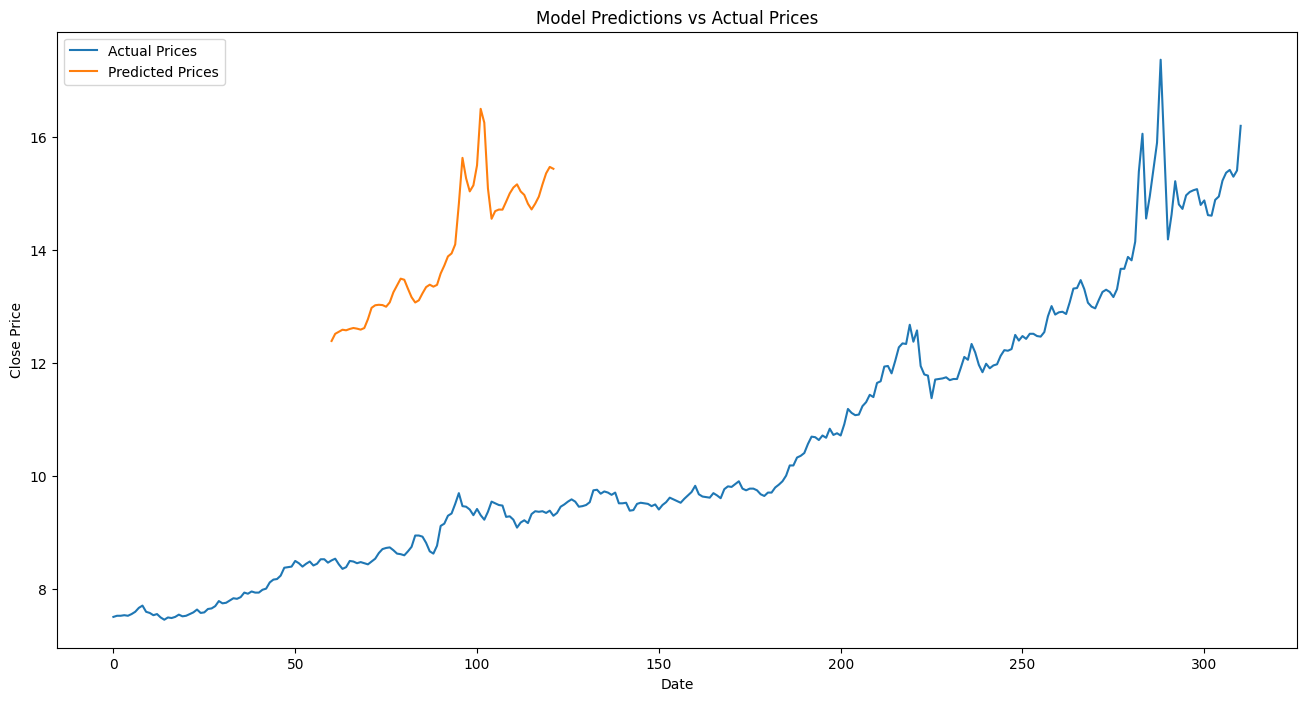

In [28]:
plt.figure(figsize=(16,8))
plt.title('Model Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')

# Shift train predictions for plotting
train_pred_plot = np.empty_like(scaled_data)
train_pred_plot[:, :] = np.nan
train_pred_plot[look_back:len(predictions)+look_back, :] = predictions

# Plot actual values
plt.plot(scaler.inverse_transform(scaled_data), label='Actual Prices')

# Plot test predictions
plt.plot(train_pred_plot, label='Predicted Prices')

plt.legend()
plt.show()

# Stock Price Prediction with LSTM

This project demonstrates how to predict stock prices using a Long Short-Term Memory (LSTM) neural network, a type of recurrent neural network well-suited for sequence prediction problems.

## Project Highlights:

*   **Data Acquisition:** Utilized the `yfinance` library to fetch historical stock data for a specified ticker symbol (e.g., `TATAGOLD.NS`).
*   **Data Preprocessing:**
    *   **Scaling:** Applied `MinMaxScaler` from `sklearn.preprocessing` to normalize stock closing prices, which is essential for stable and efficient neural network training.
    *   **Train-Test Split:** Divided the dataset into training and testing sets (80% training, 20% testing) to evaluate model performance on unseen data.
    *   **Sequence Creation:** Implemented a custom function to create input sequences (e.g., 60 previous days' prices) and corresponding target values for the LSTM model.
    *   **Reshaping for LSTM:** Reshaped the input data to the required 3D format `(samples, timesteps, features)` for LSTM layers.
*   **Model Architecture (Keras/TensorFlow):**
    *   Constructed a `Sequential` LSTM model.
    *   Included multiple `LSTM` layers (`return_sequences=True` for intermediate layers, `return_sequences=False` for the last LSTM layer).
    *   Added `Dense` layers for output projection.
*   **Model Training:**
    *   Compiled the model using the `adam` optimizer and `mean_squared_error` as the loss function, standard choices for regression tasks.
    *   Trained the model efficiently over several epochs (`epochs=10`) with a batch size of 1.
*   **Model Evaluation:**
    *   Made predictions on the `X_test` dataset.
    *   Inverse transformed the scaled predictions and actual test values back to their original price scale for interpretability.
    *   Calculated the **Root Mean Squared Error (RMSE)** to quantify the difference between predicted and actual prices. A lower RMSE indicates higher prediction accuracy.
*   **Visualization:** Plotted the actual stock prices against the model's predicted prices to visually assess the model's performance and identify trends or discrepancies.

## Technologies Used:

*   **Python**
*   **Pandas:** For data manipulation and analysis.
*   **Numpy:** For numerical operations.
*   **yfinance:** For downloading stock data.
*   **Scikit-learn (sklearn):** For data scaling (`MinMaxScaler`).
*   **Keras (TensorFlow):** For building and training the LSTM neural network.
*   **Matplotlib:** For data visualization.